# Q1: Is the report density (reports/area) higher in the city centre then in the outskirts of Zurich?
Anticipated workflow:  

0. Import the packages needed
1. Load the datasets required to calculate the report density
2. Calculate the number of reports for each neighborhood
3. Calculate the number of reports per area (the report density) for each neighborhood
4. Visually represent the report density using a choropleth map

## 0. Import packages

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
from pathlib import Path


import sys
sys.path.append("../scripts")

from functions_zh_wie_neu import import_preprocessed_data #type: ignore
from functions_zh_wie_neu import export_result_to_png #type: ignore

## 1. Loading the required datasets
To prepare the data for plotting, I need the spatially joined dataset and the quartiere_processed file, as it holds the area of each neighborhood.

In [3]:
reports_spatial=import_preprocessed_data("reports_quartiere_sjoin.gpkg")
quartiere=import_preprocessed_data("quartiere_processed.gpkg")

The active geometry column of this geodataframe is called 'geometry'.
The active geometry column of this geodataframe is called 'geometry'.


Check wheter the import worked:

In [4]:
display(quartiere.head(2))
display(reports_spatial.head(2))

,qnr,qname,knr,kname,area_km2,geometry
0,31,Alt-Wiedikon,3,Kreis 3,1.692468,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,74,Witikon,7,Kreis 7,4.933788,"POLYGON ((2685858.632 1246502.629, 2685860.738..."


,service_request_id,requested_datetime,e,n,service_code,description,index_right,qnr,qname,knr,kname,geometry
0,1,2013-03-14 15:16:15,2678968,1247548,Strasse/Trottoir/Platz,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,16,91,Albisrieden,9,Kreis 9,POINT (2678968 1247548)
1,2,2013-03-14 15:17:57,2680746,1249916,Strasse/Trottoir/Platz,Vermessungs: Vermessungspunkt ist nicht mehr b...,20,101,Höngg,10,Kreis 10,POINT (2680746 1249916)


## 2. Calculate the number of reports for each neighborhood:
The idea is to calculate who often each "qnr" exists in the reports_spatial file. 

In [5]:
# use this code: !!!!
n_reports=(
    reports_spatial
    .groupby("qname")
    .size()
    .reset_index(name="nr_reports")#this transforms the qnr to a data column named nr_reports (after the code above it was set as the index)
    .sort_values(by="nr_reports",ascending=False) #displays me the highest values first
)
display(n_reports.head(2))

,qname,nr_reports
16,Langstrasse,6222
27,Sihlfeld,5273


In [6]:
# now merge it to the quartiere dataset:
quartiere=quartiere.merge(
    n_reports,
    on="qname",
    how="left")

#quartiere=quartiere["nr_reports"]
display(quartiere.head(2))

,qnr,qname,knr,kname,area_km2,geometry,nr_reports
0,31,Alt-Wiedikon,3,Kreis 3,1.692468,"POLYGON ((2680606.662 1247034.584, 2680626.356...",2532
1,74,Witikon,7,Kreis 7,4.933788,"POLYGON ((2685858.632 1246502.629, 2685860.738...",1142


Quick sneak peak: visualising the first results

<Axes: >

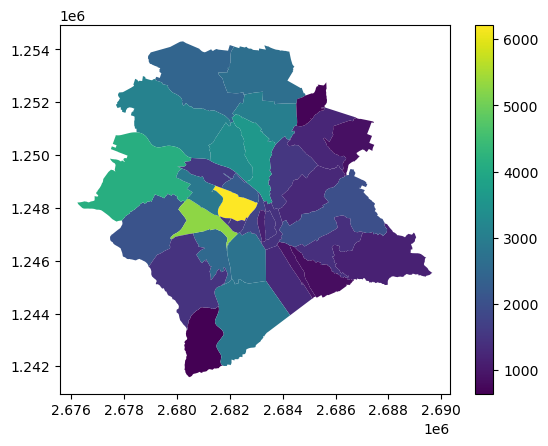

In [7]:
# quickly map this: 
fig, ax= plt.subplots()

quartiere.plot(ax=ax, column="nr_reports", legend=True)

## 3. Reports per Neighborhood Area
The idea is to calculate the "report density" of each neighborhood by dividing the number of reports by the area of each neighborhood.

In [8]:
quartiere["reports_per_km2"]=(quartiere["nr_reports"]/quartiere["area_km2"])

display(quartiere.head(2))

,qnr,qname,knr,kname,area_km2,geometry,nr_reports,reports_per_km2
0,31,Alt-Wiedikon,3,Kreis 3,1.692468,"POLYGON ((2680606.662 1247034.584, 2680626.356...",2532,1496.040296
1,74,Witikon,7,Kreis 7,4.933788,"POLYGON ((2685858.632 1246502.629, 2685860.738...",1142,231.465132


In [9]:
#checking wheter it worked --> delete this in the end!!!
print(quartiere["nr_reports"].sum())
print(quartiere["area_km2"].sum())

73243
91.87980054046378


## 4. Create the final map
* Using a scientific color map is very important. Therefore I will use the reversed hawaii color map from the cmcrameri.cm package.
* I decided to not further classigy the data to not loose the advantage of a continuous color sheme

<function matplotlib.pyplot.show(close=None, block=None)>

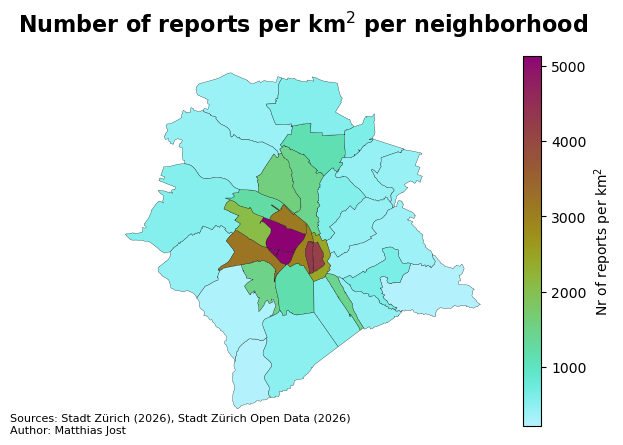

In [10]:
fig, ax= plt.subplots()

# defines the legend options
legend_options = {
    "label": "Nr of reports per km$^{2}$", 
    "orientation": "vertical", 
    "shrink": 1, 
    "pad": 0.05,  
}

#plot the layer 
quartiere.plot(ax=ax,
             column="reports_per_km2", 
             cmap=cmc.hawaii_r, 
             legend=True,
             legend_kwds=legend_options,
             edgecolor="black", linewidth=0.2
             )

#all ax commands
ax.axis("off")
ax.set_title("Number of reports per km$^{2}$ per neighborhood", fontsize=16, loc="center", fontweight="bold")
ax.text(-0.25,-0.02, "Sources: Stadt Zürich (2026), Stadt Zürich Open Data (2026) \nAuthor: Matthias Jost", transform=ax.transAxes, fontsize=8)

#export an display the final map
export_result_to_png("Q1_report_density_map")
plt.show